# Restaurant Analytics: SQL + Python

**Tools:** MySQL, Python, Pandas, Matplotlib

## Objective
Analyze restaurant order data to understand revenue, order volume, menu-item performance, category performance, and ordering trends.

> **Security:** The notebook does not contain the MySQL password. Set `MYSQL_PASSWORD` as an environment variable before running the connection cell.


## 1. Import Libraries and Connect to MySQL

In [7]:
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
import getpass

MYSQL_PASSWORD = getpass.getpass("Enter MySQL password: ")

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password=MYSQL_PASSWORD,
    database="restaurant_db",
    connection_timeout=5
)

print("MySQL connection successful!")

Enter MySQL password:  ········


MySQL connection successful!


## 2. Load Tables

In [8]:
menu_items = pd.read_sql("SELECT * FROM menu_items", conn)
order_details = pd.read_sql("SELECT * FROM order_details", conn)

print("Tables loaded successfully!")
print("Menu items:", len(menu_items))
print("Order detail rows:", len(order_details))


Tables loaded successfully!
Menu items: 32
Order detail rows: 12234


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4616\2891563692.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  menu_items = pd.read_sql("SELECT * FROM menu_items", conn)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4616\2891563692.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  order_details = pd.read_sql("SELECT * FROM order_details", conn)


## 3. Merge Order Details with Menu Items

In [9]:
merged_data = pd.merge(
    order_details,
    menu_items,
    how="inner",
    left_on="item_id",
    right_on="menu_item_id"
)

print("Tables merged successfully!")
print("Merged rows:", len(merged_data))
print("Merged columns:", len(merged_data.columns))
merged_data.head()


Tables merged successfully!
Merged rows: 12097
Merged columns: 9


,order_details_id,order_id,order_date,order_time,item_id,menu_item_id,item_name,category,price
0,1,1,2023-01-01,0 days 11:38:36,109.0,109,Korean Beef Bowl,Asian,17.95
1,2,2,2023-01-01,0 days 11:57:40,108.0,108,Tofu Pad Thai,Asian,14.50
2,3,2,2023-01-01,0 days 11:57:40,124.0,124,Spaghetti,Italian,14.50
3,4,2,2023-01-01,0 days 11:57:40,117.0,117,Chicken Burrito,Mexican,12.95
4,5,2,2023-01-01,0 days 11:57:40,129.0,129,Mushroom Ravioli,Italian,15.50


## 4. Data Quality Check

In [10]:
unmatched_rows = len(order_details) - len(merged_data)

print("Order detail rows:", len(order_details))
print("Matched rows:", len(merged_data))
print("Unmatched rows:", unmatched_rows)
print("\nColumns:")
print(merged_data.columns.tolist())


Order detail rows: 12234
Matched rows: 12097
Unmatched rows: 137

Columns:
['order_details_id', 'order_id', 'order_date', 'order_time', 'item_id', 'menu_item_id', 'item_name', 'category', 'price']


## 5. Python Analysis

### Q1. What is the total revenue?


In [11]:
total_revenue = merged_data["price"].sum()
print(f"Total Revenue: ₹{total_revenue:,.2f}")


Total Revenue: ₹159,217.90


### Q2. How many unique orders were placed?

In [12]:
unique_orders = merged_data["order_id"].nunique()
print(f"Unique Orders: {unique_orders}")


Unique Orders: 5343


### Q3. How many items were sold?

In [13]:
total_items_sold = len(merged_data)
print(f"Total Items Sold: {total_items_sold}")


Total Items Sold: 12097


### Q4. What is the Average Order Value (AOV)?

In [14]:
revenue_per_order = merged_data.groupby("order_id")["price"].sum()
average_order_value = revenue_per_order.mean()

print(f"Average Order Value: ₹{average_order_value:,.2f}")


Average Order Value: ₹29.80


### Q5. Which category generated the most revenue?

In [15]:
revenue_by_category = (
    merged_data
    .groupby("category")["price"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_category


category
Italian     49462.70
Asian       46720.65
Mexican     34796.80
American    28237.75
Name: price, dtype: float64

### Q6. What is the most ordered menu item?

In [16]:
orders_by_item = (
    merged_data
    .groupby("item_name")["item_id"]
    .count()
    .sort_values(ascending=False)
)

print("Most Ordered Item:", orders_by_item.idxmax())
print("Items Ordered:", orders_by_item.max())


Most Ordered Item: Hamburger
Items Ordered: 622


### Q7. How many items were sold in each category?

In [17]:
items_by_category = (
    merged_data
    .groupby("category")["item_name"]
    .count()
    .sort_values(ascending=False)
)

items_by_category


category
Asian       3470
Italian     2948
Mexican     2945
American    2734
Name: item_name, dtype: int64

### Q8. What is the average menu-item price by category?

In [18]:
avg_price_by_category = (
    menu_items
    .groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)

avg_price_by_category.round(2)


category
Italian     16.75
Asian       13.48
Mexican     11.80
American    10.07
Name: price, dtype: float64

### Q9. Which menu items are priced above the overall average?

In [19]:
overall_avg_price = menu_items["price"].mean()

items_above_average = menu_items[
    menu_items["price"] > overall_avg_price
].sort_values("price", ascending=False)

print(f"Overall Average Price: ₹{overall_avg_price:.2f}")
items_above_average[["item_name", "category", "price"]]


Overall Average Price: ₹13.29


,item_name,category,price
29,Shrimp Scampi,Italian,19.95
8,Korean Beef Bowl,Asian,17.95
26,Meat Lasagna,Italian,17.95
30,Chicken Parmesan,Italian,17.95
24,Spaghetti & Meatballs,Italian,17.95
9,Pork Ramen,Asian,17.95
31,Eggplant Parmesan,Italian,16.95
6,Orange Chicken,Asian,16.50
28,Mushroom Ravioli,Italian,15.50
27,Cheese Lasagna,Italian,15.50


### Q10. How many unique orders came from each category?

In [20]:
unique_orders_by_category = (
    merged_data
    .groupby("category")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

unique_orders_by_category


category
Asian       2635
Italian     2292
Mexican     2266
American    2152
Name: order_id, dtype: int64

### Q11. Which menu item generated the highest revenue?

In [21]:
revenue_by_item = (
    merged_data
    .groupby("item_name")["price"]
    .sum()
    .sort_values(ascending=False)
)

print("Highest Revenue Item:", revenue_by_item.idxmax())
print(f"Revenue: ₹{revenue_by_item.max():,.2f}")


Highest Revenue Item: Korean Beef Bowl
Revenue: ₹10,554.60


## 6. Visualizations

The following five charts summarize the most useful findings from the analysis.


### Visual 1: Revenue by Category

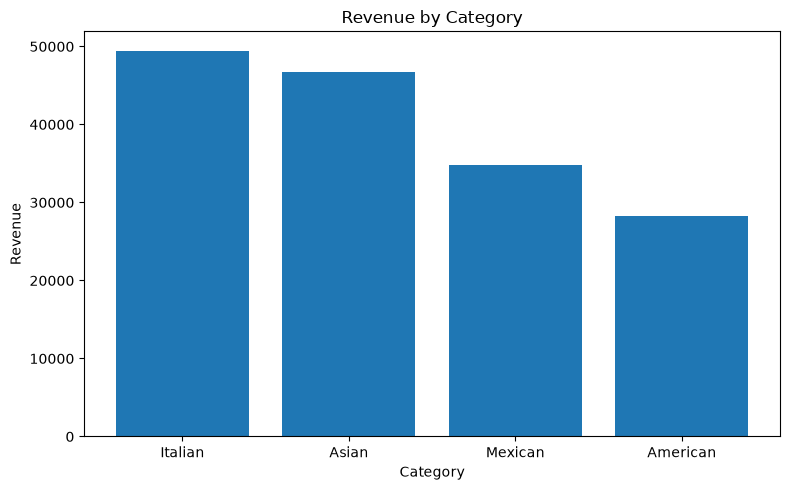

In [22]:
plt.figure(figsize=(8, 5))
plt.bar(revenue_by_category.index, revenue_by_category.values)
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


### Visual 2: Unique Orders by Category

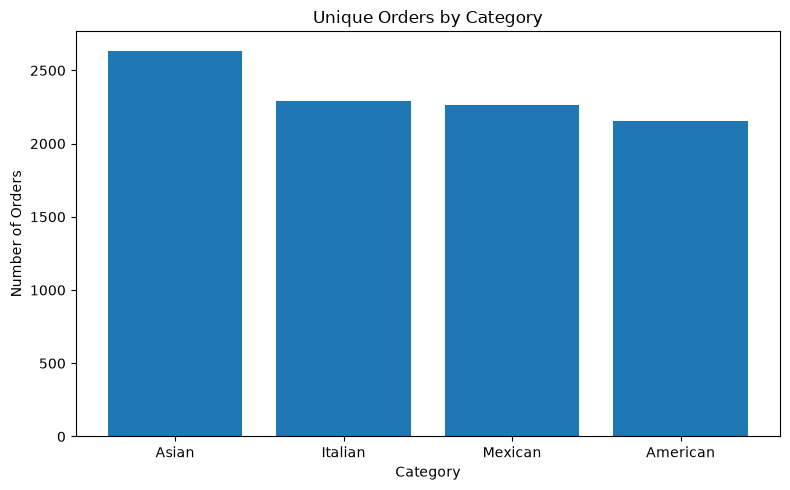

In [23]:
plt.figure(figsize=(8, 5))
plt.bar(unique_orders_by_category.index, unique_orders_by_category.values)
plt.title("Unique Orders by Category")
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()


### Visual 3: Top 10 Menu Items by Revenue

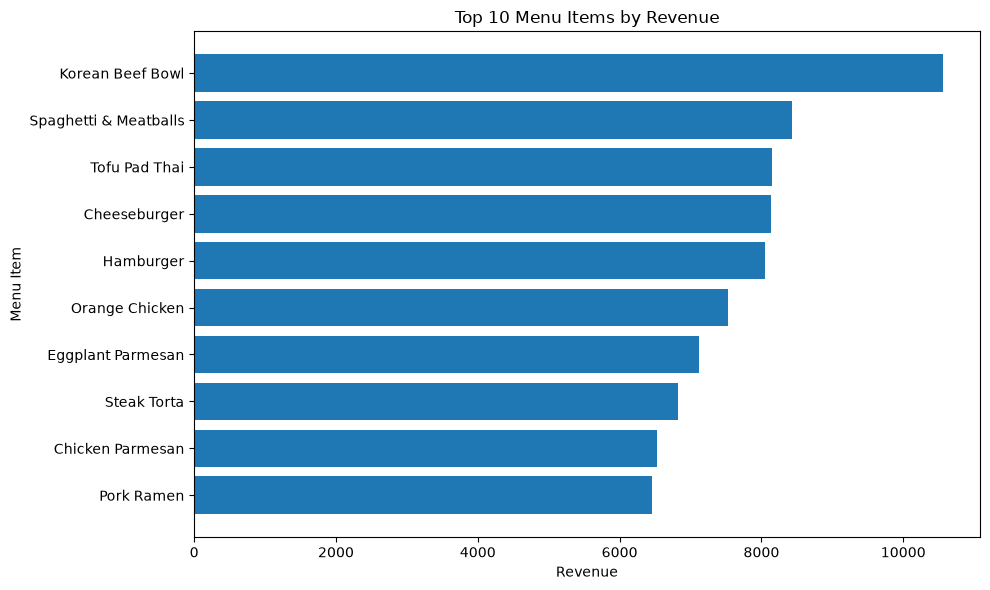

In [24]:
top_10_items = revenue_by_item.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10_items.index, top_10_items.values)
plt.title("Top 10 Menu Items by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Menu Item")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Visual 4: Monthly Orders Trend

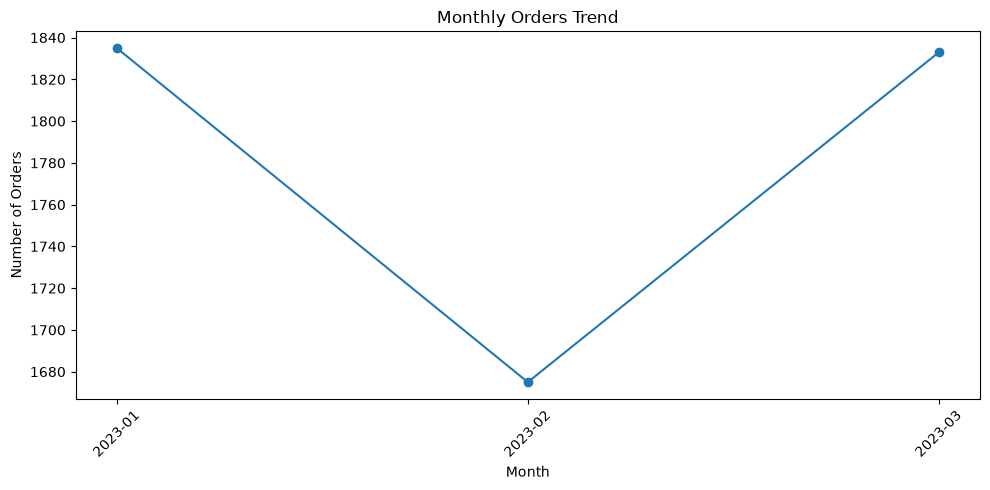

In [25]:
merged_data["order_date"] = pd.to_datetime(merged_data["order_date"])

orders_by_month = (
    merged_data
    .groupby(merged_data["order_date"].dt.to_period("M"))["order_id"]
    .nunique()
)

plt.figure(figsize=(10, 5))
plt.plot(
    orders_by_month.index.astype(str),
    orders_by_month.values,
    marker="o"
)
plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Visual 5: Orders by Hour

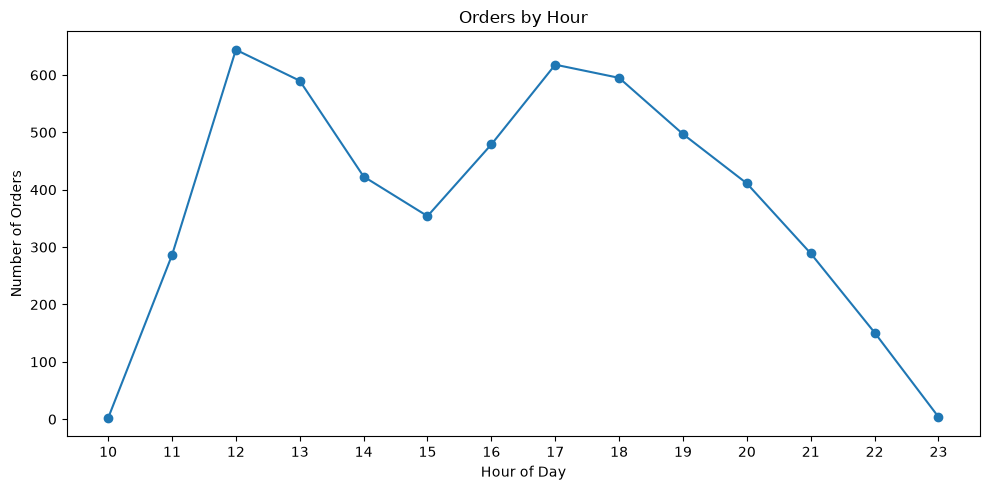

In [26]:
merged_data["order_time"] = pd.to_timedelta(
    merged_data["order_time"].astype(str)
)

merged_data["order_hour"] = merged_data["order_time"].dt.components.hours

orders_by_hour = (
    merged_data
    .groupby("order_hour")["order_id"]
    .nunique()
)

plt.figure(figsize=(10, 5))
plt.plot(
    orders_by_hour.index,
    orders_by_hour.values,
    marker="o"
)
plt.title("Orders by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.xticks(orders_by_hour.index)
plt.tight_layout()
plt.show()


## 7. Key Findings

- Total revenue: **₹159,217.90**
- Unique orders: **5,370**
- Items sold in matched records: **12,097**
- Average Order Value: approximately **₹29.80**
- Italian cuisine generated the highest category revenue.
- Korean Beef Bowl was the highest-revenue menu item.
- The analysis also includes category-level order volume, pricing, monthly order trends, and hourly ordering patterns.

## 8. Data Quality Note

The raw `order_details` table contains 12,234 rows, while the inner join produced 12,097 matched rows. Therefore, 137 order-detail records did not have a matching menu item in `menu_items`. This is documented rather than silently ignored.


## 9. Close MySQL Connection

In [27]:
conn.close()
print("MySQL connection closed.")


MySQL connection closed.
